# 实验1：个股 vs 沪深300ETF

只需修改第一个代码单元格中的 `DATA_START`、`DATA_END`，再从该单元格起依次运行（建议“重启内核并运行全部”）。结束日包含在请求区间内；非交易日无行情，以下载后显示的实际区间为准。

使用 Yahoo Finance 的 auto_adjust=True 日线价格，按标的、配置区间和复权口径缓存 CSV。归一化价格 = 当日收盘价 / 实际共同起始日收盘价，起点为 1。图表标签和缺失行情说明由数据生成。

MA20 沿用第一章：每月第一个交易日投入 1000 元；收盘价上穿均线进入多头，下穿清仓；当日收盘信号于下一交易日收盘执行。持有状态下新增现金也投入，空仓时留存现金。没有完整均线/交叉历史时保持现金；不补造区间前的历史。允许零股，手续费、滑点及现金利息均为 0，是教学模拟。

收益率曲线为“总资产 / 累计投入 − 1”，与第一章一致，并非时间加权收益率。年化波动率使用扣除当日入金后的日收益标准差 × √252，包含空仓日。额外列出时间加权收益率供核对。

In [1]:
# 日期只在此处修改；修改后请从本单元格起重新运行全部单元格。
DATA_START = "2023-03-05"
DATA_END = "2026-03-05"

from pathlib import Path
import time
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

stock_symbols = ["600519.SS", "000858.SZ", "601318.SS", "000001.SZ", "600036.SS"]
stock_names = ["贵州茅台", "五粮液", "中国平安", "平安银行", "招商银行"]
symbols = stock_symbols + ["510300.SS"]
names = stock_names + ["沪深300ETF"]
name_map = dict(zip(symbols, names))
try:
    start_ts = pd.Timestamp(DATA_START)
    end_ts = pd.Timestamp(DATA_END)
    if pd.isna(start_ts) or pd.isna(end_ts):
        raise ValueError('日期不能为空')
    if start_ts.tzinfo is not None or end_ts.tzinfo is not None:
        raise ValueError('日期无需包含时区')
    if start_ts != start_ts.normalize() or end_ts != end_ts.normalize():
        raise ValueError('请只填写日期，不要填写时分秒')
    if start_ts > end_ts:
        raise ValueError('开始日期不能晚于结束日期')
except (TypeError, ValueError) as exc:
    raise ValueError('请将 DATA_START / DATA_END 设置为有效起止日期，如 YYYY-MM-DD') from exc
DATA_START = start_ts.strftime('%Y-%m-%d')
DATA_END = end_ts.strftime('%Y-%m-%d')
print(f'配置区间：{DATA_START} 至 {DATA_END}（含结束日）')
MONTHLY_AMOUNT = 1000
ANNUAL_DAYS = 252

cwd = Path.cwd()
notebook_dir = next(
    (p for p in (cwd, cwd / 'q2', cwd / 'xquant-learning-sxl' / 'q2')
     if (p / 'what-to-buy.ipynb').is_file()), None
)
if notebook_dir is None:
    raise RuntimeError('请从 q2 或学习项目根目录启动 Notebook')
cache_dir = notebook_dir / 'data'
# Yahoo 内部 cookie / 时区缓存也放在可写的项目目录。
yf.set_tz_cache_location(str(cache_dir / 'yfinance'))
figure_dir = notebook_dir / 'figures'


配置区间：2023-03-05 至 2026-03-05（含结束日）


## 1. 下载并校验数据

已有缓存直接读取；下载失败不写空缓存，不使用其他标的或旧区间冒充成功。缓存固定一次下载的复权价格快照。重新下载可能因后续分红调整历史价格，因此比较应使用同一批快照。

In [2]:
def validate_prices(frame, symbol, start, end):
    if frame is None or frame.empty:
        raise ValueError(f'{symbol}: 没有数据')
    frame = frame.copy()
    frame.index = pd.to_datetime(frame.index)
    if frame.index.tz is not None:
        frame.index = frame.index.tz_localize(None)
    frame = frame.sort_index().loc[start:end]
    if frame.empty or 'Close' not in frame:
        raise ValueError(f'{symbol}: 缺少区间内的 Close 数据')
    if frame.index.has_duplicates or frame.index.hasnans:
        raise ValueError(f'{symbol}: 日期重复或无效')
    frame['Close'] = pd.to_numeric(frame['Close'], errors='raise')
    if not np.isfinite(frame['Close']).all() or (frame['Close'] <= 0).any():
        raise ValueError(f'{symbol}: 收盘价包含缺失、非有限值或非正数')
    # 周末和节假日不要求返回行情；实际边界由六个标的数据共同确定。
    frame.index.name = 'Date'
    return frame


def load_prices(symbol, start=None, end=None):
    # 调用时取当前配置，避免默认参数保留函数定义时的旧日期。
    start = DATA_START if start is None else start
    end = DATA_END if end is None else end
    path = cache_dir / f"{symbol.replace('.', '_')}_{start}_{end}_auto_adjust.csv"
    if path.exists():
        frame = validate_prices(pd.read_csv(path, index_col='Date', parse_dates=['Date']),
                                symbol, start, end)
        source = '缓存'
    else:
        # yfinance 的 end 为排他边界，因此加一天。
        download_end = (pd.Timestamp(end) + pd.Timedelta(days=1)).strftime('%Y-%m-%d')
        try:
            downloaded = yf.download(
                symbol, start=start, end=download_end, auto_adjust=True,
                multi_level_index=False, threads=False, progress=False, timeout=20,
            )
            frame = validate_prices(downloaded, symbol, start, end)
        except Exception as exc:
            raise RuntimeError(
                f'{symbol} 下载失败且没有有效缓存。请检查上方 Yahoo 报错；'
                '若限流请稍后重试，已成功缓存的标的无需重新下载。'
            ) from exc
        cache_dir.mkdir(parents=True, exist_ok=True)
        temporary = path.with_suffix('.csv.tmp')
        frame.to_csv(temporary)
        temporary.replace(path)
        source = '下载后缓存'
        time.sleep(2)  # 顺序下载，适当降低访问频率；不进行循环重试
    print(f'{name_map.get(symbol, symbol)} ({symbol}): {source}, {len(frame)} 行, '
          f'{frame.index[0].date()} 至 {frame.index[-1].date()}', flush=True)
    return frame


data_by_symbol = {symbol: load_prices(symbol) for symbol in symbols}
# 核查并展示日期缺口。保留各自原始数据，不前向填充、不静默删掉其他标的行情。
reference_index = data_by_symbol[symbols[0]].index
for frame in data_by_symbol.values():
    reference_index = reference_index.union(frame.index)
quality_rows = []
for symbol, frame in data_by_symbol.items():
    missing = reference_index.difference(frame.index)
    quality_rows.append({
        '标的': name_map[symbol], '行数': len(frame),
        '缺少日期(相对六者并集)': ', '.join(d.strftime('%Y-%m-%d') for d in missing) or '无',
    })
display(pd.DataFrame(quality_rows))
gap_notes = [
    f"{row['标的']} 缺少 {row['缺少日期(相对六者并集)']}"
    for row in quality_rows if row['缺少日期(相对六者并集)'] != '无'
]
if gap_notes:
    gap_footnote = '数据缺口：' + '；'.join(gap_notes) + '。对应波动率为近似估计。'
else:
    gap_footnote = '六个标的在本次下载数据的日期并集中无缺口；此检查不代替交易所日历校验。'
print('日期有缺口的标的按实际观测计算 MA20；跨缺口收益并非严格单交易日收益，'
      '其年化波动率为近似值。该缺口未用其他数据源填补。')
# 共同起止日统一比较基准；内部缺口仍保留，绝不填造行情。
common_dates = data_by_symbol[symbols[0]].index
for frame in data_by_symbol.values():
    common_dates = common_dates.intersection(frame.index)
if common_dates.empty:
    raise ValueError('该区间六个标的没有共同行情日期，无法归一化比较')
BASE_DATE, ACTUAL_END = common_dates.min(), common_dates.max()
for symbol, frame in data_by_symbol.items():
    removed = ((frame.index < BASE_DATE) | (frame.index > ACTUAL_END)).sum()
    if removed:
        print(f'{name_map[symbol]}：为统一比较边界，剔除区间两端 {removed} 条非共同行情')
    data_by_symbol[symbol] = frame.loc[BASE_DATE:ACTUAL_END].copy()
if min(len(frame) for frame in data_by_symbol.values()) < 22:
    raise ValueError('当前共同区间行情不足 22 条，请扩大日期范围以运行 MA20 回测')
close_prices = pd.DataFrame({name_map[s]: data_by_symbol[s]['Close'] for s in symbols})
period_label = f'{BASE_DATE:%Y-%m-%d} 至 {ACTUAL_END:%Y-%m-%d}'
print(f'实际共同区间：{period_label}；归一化基准日：{BASE_DATE:%Y-%m-%d}')
print('实际行情边界仅根据返回数据确定；接口整体漏报的日期需额外核对交易所日历。')


贵州茅台 (600519.SS): 缓存, 726 行, 2023-03-06 至 2026-03-05


五粮液 (000858.SZ): 缓存, 726 行, 2023-03-06 至 2026-03-05


中国平安 (601318.SS): 缓存, 726 行, 2023-03-06 至 2026-03-05


平安银行 (000001.SZ): 缓存, 726 行, 2023-03-06 至 2026-03-05


招商银行 (600036.SS): 缓存, 726 行, 2023-03-06 至 2026-03-05


沪深300ETF (510300.SS): 缓存, 725 行, 2023-03-06 至 2026-03-05


,标的,行数,缺少日期(相对六者并集)
0,贵州茅台,726,无
1,五粮液,726,无
2,中国平安,726,无
3,平安银行,726,无
4,招商银行,726,无
5,沪深300ETF,725,2025-10-24


日期有缺口的标的按实际观测计算 MA20；跨缺口收益并非严格单交易日收益，其年化波动率为近似值。该缺口未用其他数据源填补。
实际共同区间：2023-03-06 至 2026-03-05；归一化基准日：2023-03-06
实际行情边界仅根据返回数据确定；接口整体漏报的日期需额外核对交易所日历。


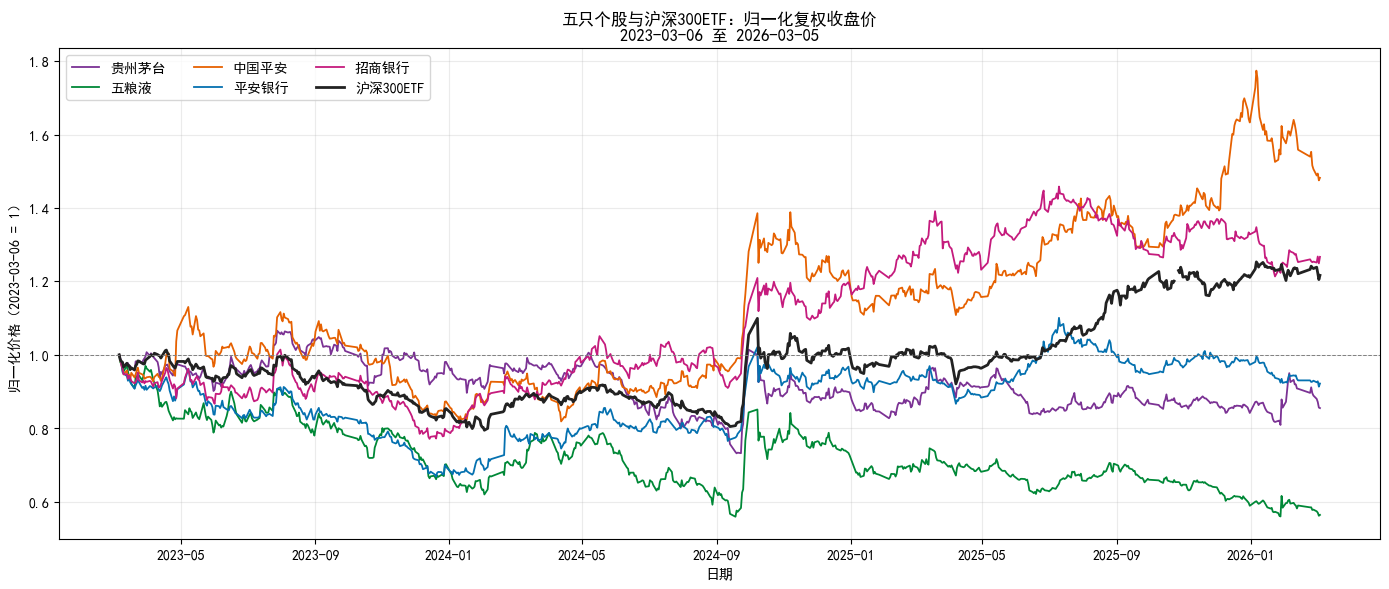

In [3]:
normalized_prices = close_prices.div(close_prices.loc[BASE_DATE])
assert np.allclose(normalized_prices.loc[BASE_DATE], 1.0)
colors = dict(zip(names, ['#7b3294', '#008837', '#e66101', '#0571b0', '#c51b7d', '#222222']))

def finish_chart(fig, filename):
    figure_dir.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    # 不同配置区间使用不同文件名，便于对照。
    target = figure_dir / f'{DATA_START}_{DATA_END}_{filename}'
    fig.savefig(target, dpi=160, bbox_inches='tight')
    plt.show()

fig, ax = plt.subplots(figsize=(14, 6))
for name in names:
    ax.plot(normalized_prices.index, normalized_prices[name], label=name,
            color=colors[name], linewidth=2 if name == '沪深300ETF' else 1.3)
ax.axhline(1, color='gray', linewidth=0.7, linestyle='--')
ax.set(title=f'五只个股与沪深300ETF：归一化复权收盘价\n{period_label}',
       xlabel='日期', ylabel=f'归一化价格（{BASE_DATE:%Y-%m-%d} = 1）')
ax.legend(ncol=3)
ax.grid(alpha=0.25)
finish_chart(fig, '01_normalized_prices.png')


## 2. 固定 MA20 策略函数

相等时不改变已有状态。收盘信号延迟一日执行；当日资产先承受此前持仓的涨跌，再入金并交易。波动率的当日日收益 =（当日收盘资产 − 当日入金）/ 前日收盘资产 − 1。首日没有前日资产，不纳入波动率统计。期末持仓按市值估值，不强制卖出。

In [4]:
def backtest_ma20(data, monthly_amount=1000):
    """固定 20 日均线；与第一章相同月度现金流和次日收盘执行规则。"""
    if monthly_amount <= 0:
        raise ValueError('每月投入必须大于 0')
    close = data['Close'].astype(float)
    if (not close.index.is_monotonic_increasing or close.index.has_duplicates
            or not np.isfinite(close).all() or (close <= 0).any()):
        raise ValueError('价格应按日期升序且唯一，并为有限正数')
    if len(close) < 22:
        raise ValueError('MA20 回测至少需要 22 个交易日')

    ma = close.rolling(20, min_periods=20).mean()
    valid = ma.notna() & ma.shift(1).notna()
    cross_up = valid & (close.shift(1) <= ma.shift(1)) & (close > ma)
    cross_down = valid & (close.shift(1) >= ma.shift(1)) & (close < ma)
    events = pd.Series(np.nan, index=close.index)
    events.loc[cross_up] = 1.0
    events.loc[cross_down] = 0.0
    position = events.ffill().fillna(0).shift(1).fillna(0).astype(int)

    cash, shares, total_contribution = 0.0, 0.0, 0.0
    previous_month, previous_equity = None, None
    records = []
    for date, price in close.items():
        month = date.to_period('M')
        contribution = float(monthly_amount) if month != previous_month else 0.0
        cash += contribution
        total_contribution += contribution
        previous_month = month
        trade = 'HOLD'
        if position.loc[date] == 1 and cash > 0:
            shares += cash / price
            cash = 0.0
            trade = 'BUY'
        elif position.loc[date] == 0 and shares > 0:
            cash += shares * price
            shares = 0.0
            trade = 'SELL'
        equity = cash + shares * price
        daily_return = ((equity - contribution) / previous_equity - 1
                        if previous_equity is not None else np.nan)
        records.append({
            'Close': price, 'ma20': ma.loc[date],
            'cross_up': cross_up.loc[date], 'cross_down': cross_down.loc[date],
            'position': position.loc[date], 'trade': trade,
            'contribution': contribution, 'total_contribution': total_contribution,
            'cash': cash, 'shares': shares, 'portfolio_value': equity,
            'return': equity / total_contribution - 1, 'daily_return': daily_return,
        })
        previous_equity = equity
    result = pd.DataFrame(records, index=close.index)
    result['nav'] = (1 + result['daily_return'].fillna(0)).cumprod()
    return result


ma20_results = {name_map[s]: backtest_ma20(data_by_symbol[s], MONTHLY_AMOUNT)
                for s in symbols}
strategy_returns = pd.DataFrame({n: r['return'] for n, r in ma20_results.items()})
strategy_daily_returns = pd.DataFrame({n: r['daily_return'] for n, r in ma20_results.items()})
annual_volatility = strategy_daily_returns.std(ddof=1) * np.sqrt(ANNUAL_DAYS)

summary = pd.DataFrame({
    '累计投入(元)': {n: r['total_contribution'].iloc[-1] for n, r in ma20_results.items()},
    '期末资产(元)': {n: r['portfolio_value'].iloc[-1] for n, r in ma20_results.items()},
    '投入收益率': strategy_returns.iloc[-1],
    '时间加权收益率': {n: r['nav'].iloc[-1] - 1 for n, r in ma20_results.items()},
    '年化波动率': annual_volatility,
}).reindex(names)
display(summary.style.format({
    '累计投入(元)': '{:,.0f}', '期末资产(元)': '{:,.2f}',
    '投入收益率': '{:.2%}', '时间加权收益率': '{:.2%}', '年化波动率': '{:.2%}',
}))


,累计投入(元),期末资产(元),投入收益率,时间加权收益率,年化波动率
贵州茅台,"37,000","34,780.01",-6.00%,-7.08%,15.80%
五粮液,"37,000","37,268.47",0.73%,-7.57%,19.39%
中国平安,"37,000","45,383.22",22.66%,14.45%,20.74%
平安银行,"37,000","38,000.63",2.70%,-0.95%,16.00%
招商银行,"37,000","41,666.39",12.61%,21.63%,16.54%
沪深300ETF,"37,000","39,740.67",7.41%,5.37%,13.77%


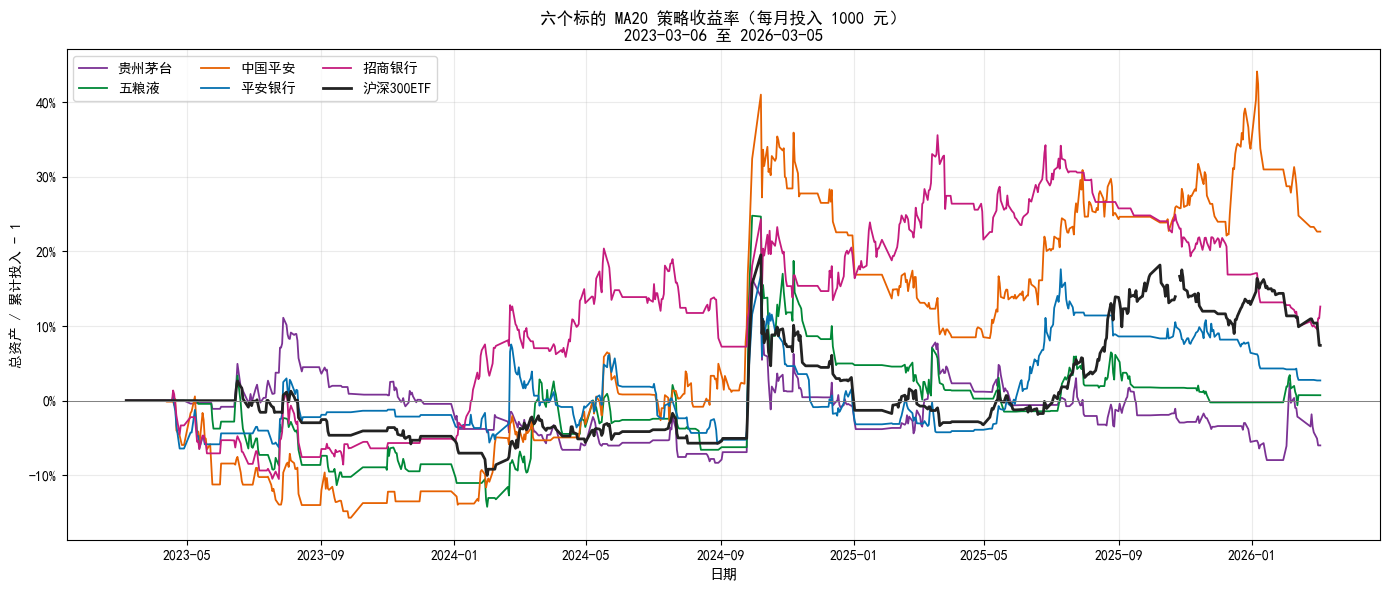

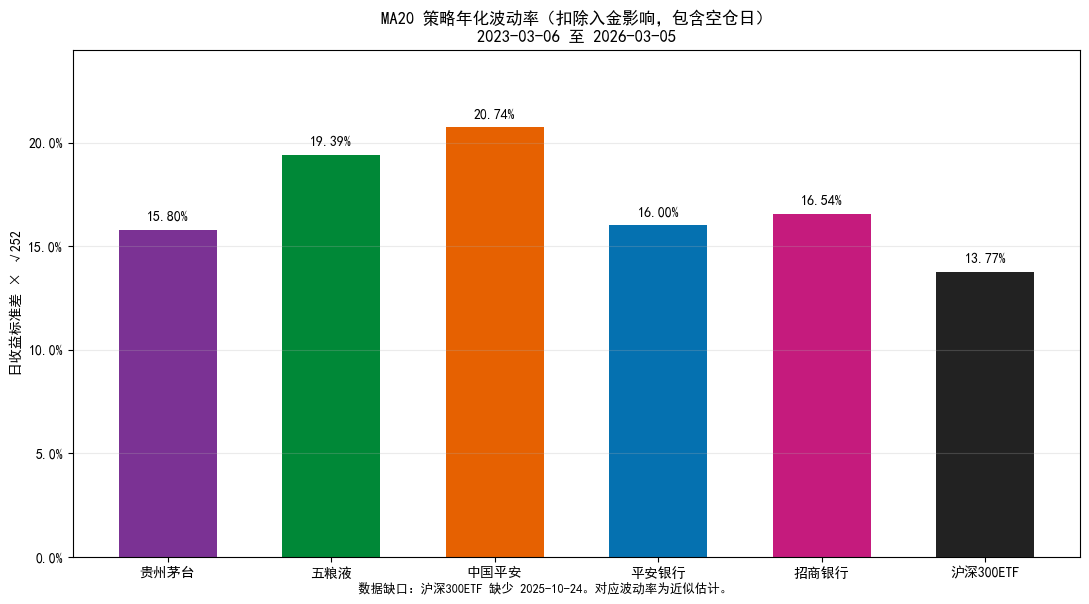

图表保存目录： D:\proj\xquant\xquant-learning-sxl\q2\figures


In [5]:
fig, ax = plt.subplots(figsize=(14, 6))
for name in names:
    ax.plot(strategy_returns.index, strategy_returns[name], label=name, color=colors[name],
            linewidth=2 if name == '沪深300ETF' else 1.3)
ax.axhline(0, color='gray', linewidth=0.7)
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set(title=f'六个标的 MA20 策略收益率（每月投入 {MONTHLY_AMOUNT} 元）\n{period_label}',
       xlabel='日期', ylabel='总资产 / 累计投入 - 1')
ax.legend(ncol=3)
ax.grid(alpha=0.25)
finish_chart(fig, '02_ma20_returns.png')

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(names, annual_volatility.reindex(names), color=[colors[n] for n in names], width=0.6)
ax.bar_label(bars, labels=[f'{v:.2%}' for v in annual_volatility.reindex(names)], padding=5)
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_ylim(0, max(float(annual_volatility.max()) * 1.18, 0.01))
ax.set(title=f'MA20 策略年化波动率（扣除入金影响，包含空仓日）\n{period_label}',
       ylabel=f'日收益标准差 × √{ANNUAL_DAYS}')
ax.grid(axis='y', alpha=0.25)
fig.text(0.5, 0.005, gap_footnote, ha='center', fontsize=9)
finish_chart(fig, '03_ma20_annual_volatility.png')
print('图表保存目录：', figure_dir.resolve())


## 实验2：黄金、纳指100、沪深300

沿用顶部日期。相关性：复权收盘价的日简单收益率 Pearson 相关系数，不对价格水平求相关。仅使用三者均有当日及前一个并集日期价格的完整收益观测，不填充缺失价格。

每月总投入相同：单资产全部投向沪深300；三资产各投入 1/3，分别执行上方 MA20 函数。各子账户独立，卖出资金留在该子账户，持有时新增现金买入；不跨账户调仓，因此是**等额投入，并非每天维持等权持仓**。MA20 暖机与次日收盘成交规则保持不变。

累计收益率沿用第一章的总资产/累计投入−1；同时列出时间加权累计收益率。年化波动率和最大回撤均基于剔除入金后的组合净值，最大回撤以正数表示。缺失行情日仅沿用上一日资产估值，不生成交易；相关结果需视为近似。

518880.SS (518880.SS): 缓存, 725 行, 2023-03-06 至 2026-03-05


513100.SS (513100.SS): 下载后缓存, 726 行, 2023-03-06 至 2026-03-05


沪深300ETF (510300.SS): 缓存, 725 行, 2023-03-06 至 2026-03-05


实际实验区间：2023-03-06 至 2026-03-05


,缺失行情日数
黄金ETF,1
纳指100ETF,0
沪深300ETF,1


存在行情缺口：估值沿用前值，波动率和回撤为近似。
相关性使用 723 个共同完整收益观测


,黄金ETF,纳指100ETF,沪深300ETF
黄金ETF,1.000,0.078,0.131
纳指100ETF,0.078,1.000,0.173
沪深300ETF,0.131,0.173,1.000


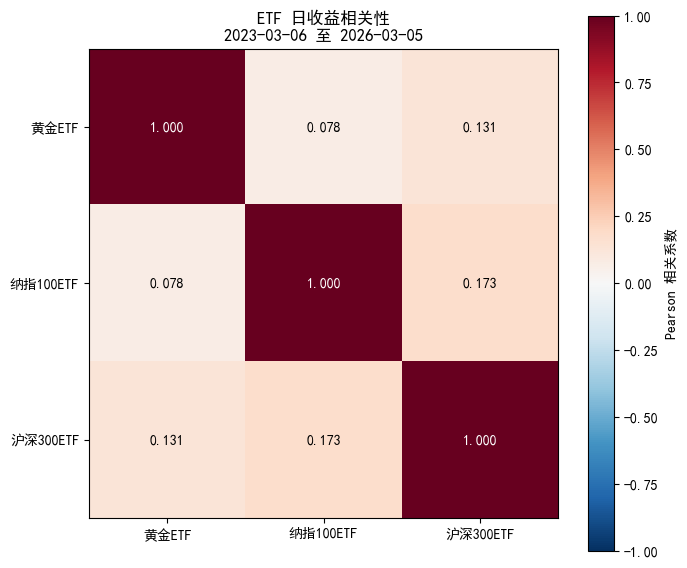

In [6]:
etf_names = {'518880.SS': '黄金ETF', '513100.SS': '纳指100ETF', '510300.SS': '沪深300ETF'}
etf_data = {s: load_prices(s) for s in etf_names}
etf_common = etf_data['510300.SS'].index
for frame in etf_data.values():
    etf_common = etf_common.intersection(frame.index)
if len(etf_common) < 22:
    raise ValueError('三只 ETF 共同行情不足 22 日，请扩大日期范围')
etf_start, etf_end = etf_common.min(), etf_common.max()
etf_data = {s: d.loc[etf_start:etf_end].copy() for s, d in etf_data.items()}
etf_prices = pd.DataFrame({etf_names[s]: d['Close'] for s, d in etf_data.items()})
etf_label = f'{etf_start:%Y-%m-%d} 至 {etf_end:%Y-%m-%d}'
etf_gaps = etf_prices.isna().sum()
print(f'实际实验区间：{etf_label}')
display(etf_gaps.rename('缺失行情日数').to_frame())
etf_gap_note = ('存在行情缺口：估值沿用前值，波动率和回撤为近似。'
                if etf_gaps.any() else '本次三只 ETF 日期一致。')
print(etf_gap_note)

etf_daily = etf_prices.pct_change(fill_method=None).dropna(how='any')
if len(etf_daily) < 2:
    raise ValueError('共同日收益样本不足')
etf_correlation = etf_daily.corr(method='pearson')
print(f'相关性使用 {len(etf_daily)} 个共同完整收益观测')
display(etf_correlation.style.format('{:.3f}'))

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(etf_correlation, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(3), etf_correlation.columns)
ax.set_yticks(range(3), etf_correlation.index)
for i in range(3):
    for j in range(3):
        v = etf_correlation.iloc[i, j]
        ax.text(j, i, f'{v:.3f}', ha='center', va='center',
                color='white' if abs(v) > 0.65 else 'black')
fig.colorbar(im, ax=ax, label='Pearson 相关系数')
ax.set_title(f'ETF 日收益相关性\n{etf_label}')
finish_chart(fig, '04_etf_correlation.png')


C:\Users\27223\AppData\Local\Temp\ipykernel_15668\3885936817.py:3: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  equity = pd.concat([a['portfolio_value'] for a in accounts], axis=1).sort_index().ffill()
C:\Users\27223\AppData\Local\Temp\ipykernel_15668\3885936817.py:4: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  flows = pd.concat([a['contribution'] for a in accounts], axis=1).reindex(equity.index).fillna(0)


,累计投入(元),期末资产(元),累计收益率(投入口径),时间加权累计收益率,年化波动率,最大回撤
只买沪深300（MA20）,"37,000.00","39,740.67",7.41%,5.37%,13.76%,18.85%
三只ETF等额投入（MA20）,"37,000.00","46,319.81",25.19%,46.69%,9.59%,7.62%


                     累计投入(元)      期末资产(元)  累计收益率(投入口径)  时间加权累计收益率    年化波动率     最大回撤
只买沪深300（MA20）   37000.000000 39740.673305     0.074072   0.053702 0.137645 0.188494
三只ETF等额投入（MA20） 37000.000000 46319.806655     0.251887   0.466863 0.095894 0.076235


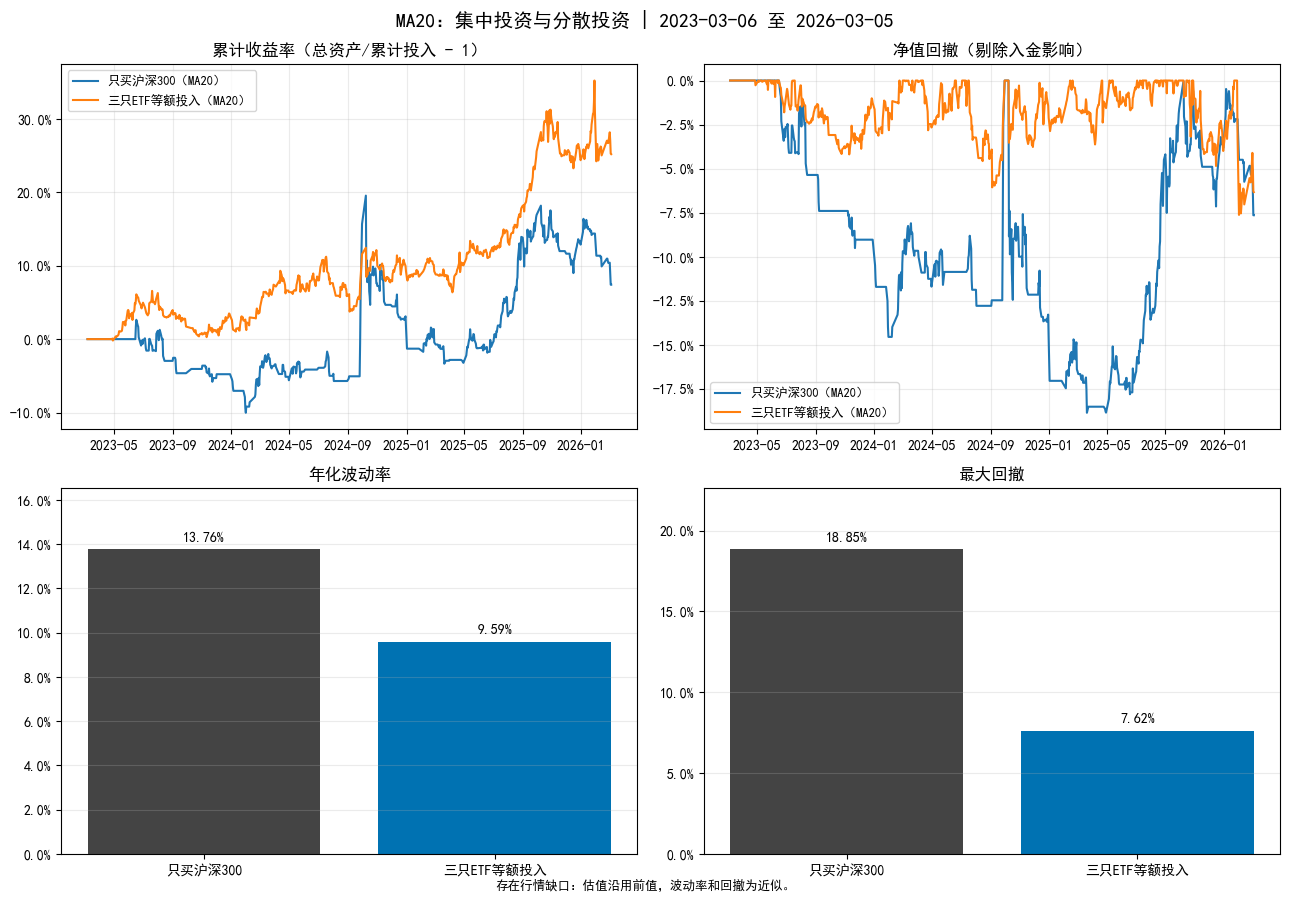

In [7]:
def combine_ma20_accounts(accounts):
    """合计子账户资产与入金，再计算组合日收益；不平均各账户收益率。"""
    equity = pd.concat([a['portfolio_value'] for a in accounts], axis=1).sort_index().ffill()
    flows = pd.concat([a['contribution'] for a in accounts], axis=1).reindex(equity.index).fillna(0)
    if equity.isna().any().any():
        raise ValueError('子账户起始日期不同，无法合计')
    result = pd.DataFrame({'portfolio_value': equity.sum(axis=1),
                           'contribution': flows.sum(axis=1)})
    result['total_contribution'] = result['contribution'].cumsum()
    result['return'] = result['portfolio_value'] / result['total_contribution'] - 1
    result['daily_return'] = ((result['portfolio_value'] - result['contribution'])
                              / result['portfolio_value'].shift(1) - 1)
    result['nav'] = (1 + result['daily_return'].fillna(0)).cumprod()
    result['drawdown'] = result['nav'] / result['nav'].cummax() - 1
    return result


etf_sleeves = [backtest_ma20(d, MONTHLY_AMOUNT / 3) for d in etf_data.values()]
# 基准补齐相同估值日；缺失日不交易，估值沿用前值。
etf_single = backtest_ma20(etf_data['510300.SS'], MONTHLY_AMOUNT)
etf_single = etf_single.reindex(etf_prices.index)
etf_single['portfolio_value'] = etf_single['portfolio_value'].ffill()
etf_single['contribution'] = etf_single['contribution'].fillna(0)
etf_portfolios = {
    '只买沪深300（MA20）': combine_ma20_accounts([etf_single]),
    '三只ETF等额投入（MA20）': combine_ma20_accounts(etf_sleeves),
}
single, diversified = etf_portfolios.values()
np.testing.assert_allclose(single['contribution'], diversified['contribution'], atol=1e-8)
etf_metrics = pd.DataFrame({
    name: {
        '累计投入(元)': r['total_contribution'].iloc[-1],
        '期末资产(元)': r['portfolio_value'].iloc[-1],
        '累计收益率(投入口径)': r['return'].iloc[-1],
        '时间加权累计收益率': r['nav'].iloc[-1] - 1,
        '年化波动率': r['daily_return'].std(ddof=1) * np.sqrt(ANNUAL_DAYS),
        '最大回撤': -r['drawdown'].min(),
    } for name, r in etf_portfolios.items()
}).T
display(etf_metrics.style.format({
    c: ('{:,.2f}' if '(元)' in c else '{:.2%}') for c in etf_metrics.columns
}))
print(etf_metrics.to_string(float_format=lambda v: f'{v:.6f}'))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for name, r in etf_portfolios.items():
    axes[0, 0].plot(r.index, r['return'], label=name)
    axes[0, 1].plot(r.index, r['drawdown'], label=name)
axes[0, 0].set_title('累计收益率（总资产/累计投入 - 1）')
axes[0, 1].set_title('净值回撤（剔除入金影响）')
for ax in axes[0]:
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.legend(fontsize=9)
    ax.grid(alpha=0.25)
for ax, metric in zip(axes[1], ['年化波动率', '最大回撤']):
    bars = ax.bar(['只买沪深300', '三只ETF等额投入'], etf_metrics[metric],
                  color=['#444444', '#0072B2'])
    ax.bar_label(bars, labels=[f'{v:.2%}' for v in etf_metrics[metric]], padding=4)
    ax.set_ylim(0, max(float(etf_metrics[metric].max()) * 1.2, 0.01))
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.set_title(metric)
    ax.grid(axis='y', alpha=0.25)
fig.suptitle(f'MA20：集中投资与分散投资 | {etf_label}', fontsize=14)
fig.text(0.5, 0.002, etf_gap_note, ha='center', fontsize=9)
finish_chart(fig, '05_etf_portfolio_comparison.png')
